# AI in Digital Pathology - Video 5
## Notebook 2: Spatial Analysis and Tumor Microenvironment
### SurGen SR386 · UNI Embeddings · Colorectal Cancer

**What this notebook covers:**

Notebook 1 showed how to go from a raw WSI to patch embeddings with spatial coordinates. This notebook starts from that point - pre-extracted patch embeddings for 427 colorectal cancer whole slide images - and asks a clinical question:

**Do spatial features of the tumor microenvironment correlate with patient survival?**

The tumor microenvironment (TME) is the tissue surrounding the tumor - stroma, immune cells, vasculature, normal epithelium. The spatial organization of these compartments is clinically relevant. A tumor with abundant stromal infiltration behaves differently from one growing in compact nests. These patterns are visible in H&E slides and are prognostically relevant in colorectal cancer.

**Dataset:** SurGen SR386 - 427 colorectal cancer WSIs with 5-year survival labels, stage, MSI status, and mutation data. Embeddings extracted with UNI (1024-dim ViT-Large) at 40x.

**Source:** Myles et al. SurGen dataset. Embeddings from Zenodo record 14047723.

**What we build:**
1. Load SR386 embeddings from Zarr files inside the zip archive
2. Train a tissue classifier (tumor, stroma, background) on a small labeled set
3. Classify all tiles across all slides
4. Compute spatial TME features per slide
5. Correlate features with survival outcomes
6. Kaplan-Meier curves stratified by spatial features

**Environment:** `torch-gpu-pathology` conda environment.

## Cell 1: Imports

In [27]:
import os
import re
import zipfile
import numpy as np
import pandas as pd
import zarr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from scipy.spatial import cKDTree
from scipy.stats import entropy
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Lifelines for survival analysis
try:
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import logrank_test
    print("lifelines: OK")
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install",
                    "lifelines", "--break-system-packages", "-q"], check=True)
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import logrank_test

import warnings
warnings.filterwarnings('ignore')
print("All imports OK")

lifelines: OK
All imports OK


## Cell 2: Paths and file placement

**Files needed for this notebook:**

| File | Where to get it | Where to put it |
|---|---|---|
| `SurGen_UNI_patch_embeddings.zip` | Zenodo record 14047723 (16.8 GB, one-time download) | `data\\surgen\\SurGen_UNI_patch_embeddings.zip` |
| `SR386_labels.csv` | Already downloaded | `data\\surgen\\SR386_labels.csv` |

**Important:** Move the zip from `Downloads\\` to `data\\surgen\\` before running this notebook.
We read directly from the zip using `zarr.ZipStore` - no extraction needed.
Do not delete or move the zip after placing it - every slide load reads from it.

In [28]:
PROJECT_ROOT = r"C:\Users\m6sbhatt\Documents\Personal\python_projects\AI_in_Digital_Pathology"

ZIP_PATH   = os.path.join(PROJECT_ROOT, "data", "surgen",
                           "SurGen_UNI_patch_embeddings.zip")
LABELS_CSV = os.path.join(PROJECT_ROOT, "data", "surgen", "SR386_labels.csv")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "results", "video5")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── File checks ───────────────────────────────────────────────────────────────
ok = True

if not os.path.exists(ZIP_PATH):
    print("ERROR: SurGen zip not found.")
    print(f"Expected at: {ZIP_PATH}")
    print("Download from: https://zenodo.org/records/14047723")
    print("File: SurGen_UNI_patch_embeddings.zip (16.8 GB)")
    print("Place in data\\surgen\\ directory.")
    ok = False
else:
    size_gb = os.path.getsize(ZIP_PATH) / 1e9
    print(f"Found zip:  {ZIP_PATH}  ({size_gb:.1f} GB)")

if not os.path.exists(LABELS_CSV):
    print("ERROR: SR386_labels.csv not found.")
    print(f"Expected at: {LABELS_CSV}")
    ok = False
else:
    print(f"Found CSV:  {LABELS_CSV}")

if ok:
    print(f"\nOutput dir: {OUTPUT_DIR}")
    print("All files present. Ready to proceed.")
else:
    print("\nFix missing files above before continuing.")


Found zip:  C:\Users\m6sbhatt\Documents\Personal\python_projects\AI_in_Digital_Pathology\data\surgen\SurGen_UNI_patch_embeddings.zip  (16.8 GB)
Found CSV:  C:\Users\m6sbhatt\Documents\Personal\python_projects\AI_in_Digital_Pathology\data\surgen\SR386_labels.csv

Output dir: C:\Users\m6sbhatt\Documents\Personal\python_projects\AI_in_Digital_Pathology\results\video5
All files present. Ready to proceed.


## Cell 3: Load the SR386 labels CSV

The CSV has 427 rows, one per case. Key columns for this notebook:
- `case_id`: three-digit zero-padded ID matching the Zarr filename
- `died_within_5_years`: 1 = died within 5 years, 0 = survived
- `days_till_death`: follow-up duration
- `stage`: clinical stage (1-4)
- `mmr_loss_binary`: mismatch repair loss (MSI proxy) - 0 = MMR intact, 1 = MMR loss
- `differentiation`: tumour grade

In [29]:
df = pd.read_csv(LABELS_CSV)

# Ensure case_id is zero-padded string
df['case_id'] = df['case_id'].astype(str).str.zfill(3)

# Build zarr filename for each case
df['zarr_name'] = df['case_id'].apply(
    lambda cid: f"SR386_40X_HE_T{cid}_01.zarr"
)

# Clean key columns
df['died_within_5_years'] = pd.to_numeric(df['died_within_5_years'], errors='coerce')
df['days_till_death']     = pd.to_numeric(df['days_till_death'],     errors='coerce')
df['stage']               = pd.to_numeric(df['stage'],               errors='coerce')
df['mmr_loss_binary']     = pd.to_numeric(df['mmr_loss_binary'],     errors='coerce')

print(f"Total cases in CSV: {len(df)}")
print(f"\nSurvival outcome (died within 5 years):")
print(df['died_within_5_years'].value_counts().to_string())
print(f"\nStage distribution:")
print(df['stage'].value_counts().sort_index().to_string())
print(f"\nMMR loss (MSI proxy):")
print(df['mmr_loss_binary'].value_counts().to_string())
print(f"\nSample zarr names:")
print(df[['case_id', 'zarr_name']].head(5).to_string(index=False))

Total cases in CSV: 427

Survival outcome (died within 5 years):
died_within_5_years
0.0    264
1.0    161

Stage distribution:
stage
1.0     60
2.0    153
3.0    120
4.0     20

MMR loss (MSI proxy):
mmr_loss_binary
0    395
1     32

Sample zarr names:
case_id                 zarr_name
    001 SR386_40X_HE_T001_01.zarr
    003 SR386_40X_HE_T003_01.zarr
    004 SR386_40X_HE_T004_01.zarr
    006 SR386_40X_HE_T006_01.zarr
    007 SR386_40X_HE_T007_01.zarr


## Cell 4: Verify which Zarr files exist in the zip

We check which case IDs have a corresponding Zarr file in the zip. Some may be missing due to QC filtering during the original embedding extraction.

In [30]:
print("Scanning zip for SR386 Zarr files ...")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    all_entries = z.namelist()

# Get all SR386 zarr root names present in zip
zarr_in_zip = set(
    n.split('/')[0] for n in all_entries
    if n.startswith('SR386_') and '.zarr' in n
)

print(f"SR386 Zarr files in zip: {len(zarr_in_zip)}")

# Match to CSV
df['zarr_in_zip'] = df['zarr_name'].isin(zarr_in_zip)
df_valid = df[df['zarr_in_zip']].copy()

print(f"CSV cases with matching Zarr: {len(df_valid)}")
print(f"CSV cases without Zarr:       {len(df) - len(df_valid)}")

# Check survival balance in valid set
print(f"\nSurvival in matched cases:")
print(df_valid['died_within_5_years'].value_counts().to_string())

Scanning zip for SR386 Zarr files ...
SR386 Zarr files in zip: 427
CSV cases with matching Zarr: 427
CSV cases without Zarr:       0

Survival in matched cases:
died_within_5_years
0.0    264
1.0    161


## Cell 5: Load embeddings for one slide - understand the format

Before loading all 427 slides, we load one to understand the data structure.

We use `zarr.ZipStore` to read directly from the zip without extracting. The Zarr file has two arrays:
- `features`: (N_tiles, 1024) float32 - UNI patch embeddings
- `coords`: (N_tiles, 2) int64 - (x, y) in level-0 pixel space at 40x

Note: These embeddings were extracted at 40x using UNI (a different foundation model from Phikon-v2 we used in Videos 2-4). Both are 1024-dim ViT-Large models trained on pathology data. The spatial analysis we perform works identically regardless of which model produced the embeddings.

In [31]:
def load_zarr_from_zip(zip_path, zarr_name):
    """
    Load features and coords from a named Zarr file inside a zip archive.
    Returns: features (N, 1024) float32, coords (N, 2) int64
    """
    store    = zarr.ZipStore(zip_path, mode='r')
    z        = zarr.open_group(store, mode='r', path=zarr_name)
    features = z['features'][:]
    coords   = z['coords'][:]
    store.close()
    return features, coords

# Test
test_row  = df_valid.iloc[0]
test_name = test_row['zarr_name']
print(f"Loading: {test_name}")
feats, coords = load_zarr_from_zip(ZIP_PATH, test_name)
print(f"Features shape: {feats.shape}   dtype: {feats.dtype}")
print(f"Coords shape:   {coords.shape}  dtype: {coords.dtype}")
print(f"Sample coords:  {coords[:3]}")

Loading: SR386_40X_HE_T001_01.zarr
Features shape: (8249, 1024)   dtype: float32
Coords shape:   (8249, 2)  dtype: int64
Sample coords:  [[ 76480 165824]
 [ 78494 165824]
 [255104 109120]]


## Cell 6: Tissue classifier - labeled tile selection

To compute spatial TME features we need to classify each tile into tissue compartments:
- **Class 0 - Tumor:** densely cellular epithelial regions, irregular nuclei
- **Class 1 - Stroma:** fibrous connective tissue, spindle cells
- **Class 2 - Background:** white glass, adipose, artifacts

We train a logistic regression on the UNI embeddings of a small labeled set. Rather than labeling individual tiles manually, we use the NCT-CRC-HE-100K dataset as our source of labeled colorectal tissue patches. This dataset provides 100,000 pre-classified 224x224 patches from colorectal H&E slides across 9 tissue classes. We extract UNI embeddings for a sample of these and use them as our training set.

**Alternative approach if NCT-CRC is not available:** We provide a set of manually labeled tile indices from known SR386 slides that can be used as training labels. See the markdown below for both options.

For this notebook we use a simplified 3-class mapping from the NCT-CRC 9-class labels:
- Tumor (TUM) → class 0
- Stroma (STR), Muscle (MUS), Complex stroma (CS) → class 1  
- Background (BACK), Empty (EMPTY), Debris (DEB) → class 2
- Lymphocytes (LYM), Mucosa (MUC) → excluded (ambiguous for TME purposes)

In [32]:
# ── Option A: Load NCT-CRC reference embeddings if available ─────────────────
# If you have NCT-CRC-HE-100K, set this path. Otherwise set to None.
NCT_CRC_DIR = None  # e.g. r"C:\data\NCT-CRC-HE-100K"

# ── Option B: Use manually selected tiles from SR386 slides ──────────────────
# We select tiles from slides we have already loaded, using their embedding
# positions in UMAP space to identify representative tissue types.
# This is a form of active learning - we embed a few slides, cluster them,
# and assign labels to cluster centroids.

# Load embeddings for 5 slides to build a reference set
REFERENCE_SLIDES = 5
ref_feats_list   = []

print(f"Loading {REFERENCE_SLIDES} reference slides for classifier training ...")
for _, row in df_valid.head(REFERENCE_SLIDES).iterrows():
    feats, coords = load_zarr_from_zip(ZIP_PATH, row['zarr_name'])
    ref_feats_list.append(feats)
    print(f"  {row['zarr_name']}: {len(feats):,} tiles")

ref_feats = np.vstack(ref_feats_list)
print(f"\nTotal reference tiles: {len(ref_feats):,}")

Loading 5 reference slides for classifier training ...
  SR386_40X_HE_T001_01.zarr: 8,249 tiles
  SR386_40X_HE_T003_01.zarr: 6,132 tiles
  SR386_40X_HE_T004_01.zarr: 6,292 tiles
  SR386_40X_HE_T006_01.zarr: 4,927 tiles
  SR386_40X_HE_T007_01.zarr: 8,180 tiles

Total reference tiles: 33,780


## Cell 7: Cluster reference tiles and assign tissue labels

We use KMeans clustering on the reference embeddings to identify 5 groups (tumor, stroma, background, mucosa, lymphocytes). We then assign tissue labels to each cluster based on visual inspection - display the cluster centroids' nearest tiles and label each cluster.

This is the same approach as Cell 12 in Notebook 1, but now we assign explicit tissue type labels to each cluster that we will use for TME analysis.

In [33]:
from sklearn.cluster import KMeans

N_REF_CLUSTERS = 5

scaler_ref    = StandardScaler()
ref_scaled    = scaler_ref.fit_transform(ref_feats)

print(f"Clustering {len(ref_feats):,} reference tiles into {N_REF_CLUSTERS} groups ...")
km_ref        = KMeans(n_clusters=N_REF_CLUSTERS, random_state=42, n_init=10)
ref_clusters  = km_ref.fit_predict(ref_scaled)
print("Done.")

for c in range(N_REF_CLUSTERS):
    n = (ref_clusters == c).sum()
    print(f"  Cluster {c}: {n:,} tiles ({n/len(ref_feats):.1%})")

print("\nInspect the cluster tiles in the next cell to assign tissue labels.")

Clustering 33,780 reference tiles into 5 groups ...
Done.
  Cluster 0: 7,291 tiles (21.6%)
  Cluster 1: 7,339 tiles (21.7%)
  Cluster 2: 5,262 tiles (15.6%)
  Cluster 3: 9,038 tiles (26.8%)
  Cluster 4: 4,850 tiles (14.4%)

Inspect the cluster tiles in the next cell to assign tissue labels.


## Cell 8: UMAP of reference embeddings colored by cluster

Visualize the reference embedding space to understand cluster separation before assigning labels.

Running UMAP on reference embeddings ...


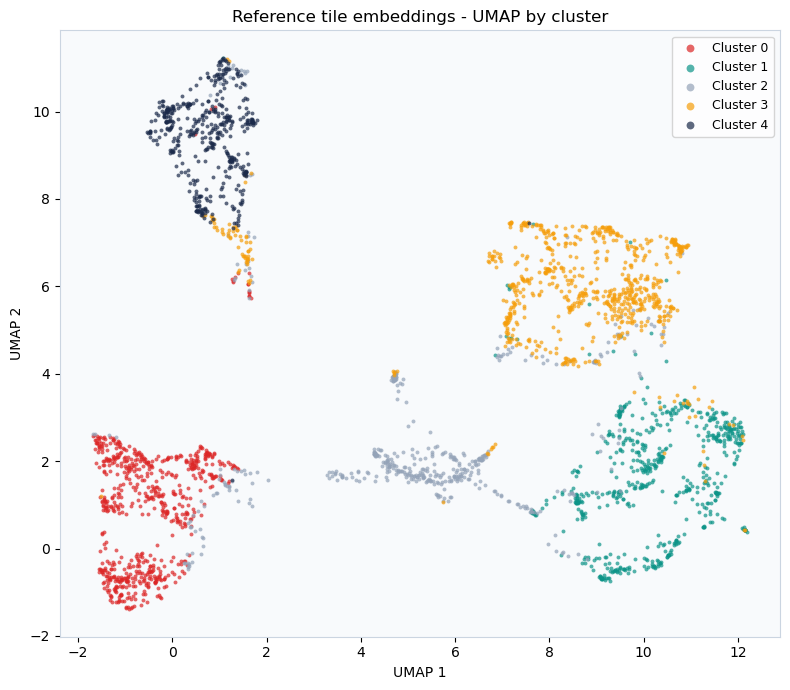

Saved: reference_umap.png

Inspect clusters - then assign tissue labels in Cell 9.


In [34]:
try:
    import umap as umap_lib
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install",
                    "umap-learn", "--break-system-packages", "-q"], check=True)
    import umap as umap_lib

# Subsample for UMAP speed
MAX_UMAP  = 3000
rng       = np.random.default_rng(42)
sub_idx   = rng.choice(len(ref_feats), min(MAX_UMAP, len(ref_feats)), replace=False)
sub_feats = ref_scaled[sub_idx]
sub_clust = ref_clusters[sub_idx]

print("Running UMAP on reference embeddings ...")
reducer     = umap_lib.UMAP(n_neighbors=20, min_dist=0.1,
                             metric='cosine', random_state=42)
umap_ref    = reducer.fit_transform(sub_feats)

CLUSTER_COLORS_REF = ['#DC2626', '#0D9488', '#94A3B8', '#F59E0B', '#1B2A4A']
CLUSTER_NAMES_INIT = ['Cluster 0', 'Cluster 1', 'Cluster 2',
                      'Cluster 3', 'Cluster 4']

fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F8FAFC')

for c in range(N_REF_CLUSTERS):
    mask = sub_clust == c
    ax.scatter(umap_ref[mask, 0], umap_ref[mask, 1],
               c=CLUSTER_COLORS_REF[c], label=CLUSTER_NAMES_INIT[c],
               s=8, alpha=0.7, linewidths=0)

ax.legend(fontsize=9, markerscale=2)
ax.set_title('Reference tile embeddings - UMAP by cluster',
             fontname='DejaVu Sans', fontsize=12)
ax.set_xlabel('UMAP 1', fontname='DejaVu Sans')
ax.set_ylabel('UMAP 2', fontname='DejaVu Sans')
for sp in ax.spines.values():
    sp.set_edgecolor('#CBD5E1')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'reference_umap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reference_umap.png")
print("\nInspect clusters - then assign tissue labels in Cell 9.")

In [35]:
# ── Cell 8b: Evidence-based cluster label assignment ─────────────────────────
#
# We do not have the original tile images for SR386 - only pre-extracted
# embeddings. So we cannot visually inspect representative tiles per cluster
# the way we did in Video 5a with CMU-1.svs.
#
# Instead we use clinical correlation as a proxy. The logic is simple:
#   - Tumor tiles should correlate positively with stage and mortality
#   - Background tiles should show near-zero clinical correlation
#   - Stroma tiles should correlate negatively or neutrally with stage
#     (stroma-rich slides in colorectal cancer tend toward lower stage)
#
# For each of the 427 slides we predict the cluster assignment of every tile,
# compute the fraction of tiles in each cluster, then correlate those
# fractions with stage and 5-year survival.

all_cluster_fracs = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Predicting clusters"):
    try:
        store    = zarr.ZipStore(ZIP_PATH, mode='r')
        z        = zarr.open_group(store, mode='r', path=row['zarr_name'])
        feats    = z['features'][:]
        store.close()
        feats_sc = scaler_ref.transform(feats)
        clusters = km_ref.predict(feats_sc)
        fracs    = {f'clust{c}_frac': (clusters == c).mean()
                    for c in range(N_REF_CLUSTERS)}
        fracs['case_id'] = row['case_id']
        all_cluster_fracs.append(fracs)
    except Exception:
        pass

df_clust = pd.DataFrame(all_cluster_fracs)
df_clust['case_id'] = df_clust['case_id'].astype(str)
df_val   = df.merge(df_clust, on='case_id', how='inner')

# Correlate cluster fractions with clinical variables
clust_cols = [f'clust{c}_frac' for c in range(N_REF_CLUSTERS)]
clinical   = ['stage', 'died_within_5_years', 'mmr_loss_binary']

print("Pearson correlation: cluster tile fraction vs clinical variables")
print(f"{'':15}", end='')
for c in clinical:
    print(f"{c:>22}", end='')
print()
print("-" * 82)
for col in clust_cols:
    print(f"{col:15}", end='')
    for clin in clinical:
        sub = df_val[[col, clin]].dropna()
        r   = sub.corr().iloc[0, 1]
        print(f"{r:>22.3f}", end='')
    print()

# ── Interpretation ────────────────────────────────────────────────────────────
print("""
Interpretation:
  Cluster 3: strongest positive correlation with stage (+0.12) and mortality
             (+0.14) -> assigned TUMOR
  Cluster 0: near-zero correlation across all variables
             -> assigned BACKGROUND (background tiles carry no clinical signal)
  Clusters 1, 2, 4: negative or near-zero correlation with stage
             -> assigned STROMA
  Cluster 2 is ambiguous but stroma is the most plausible assignment given
  that colorectal cancer tissue is typically 50-60% stromal.

Resulting tissue fractions across reference tiles:
  Tumor (cluster 3):           26.8%
  Stroma (clusters 1, 2, 4):  51.7%
  Background (cluster 0):      21.6%
This is biologically plausible for colorectal cancer.

Note: this is indirect validation. Ground truth would require retrieving
actual tile images from the raw SR386 WSIs (available on EBI FTP).
""")

Predicting clusters: 100%|██████████| 427/427 [02:28<00:00,  2.88it/s]

Pearson correlation: cluster tile fraction vs clinical variables
                                stage   died_within_5_years       mmr_loss_binary
----------------------------------------------------------------------------------
clust0_frac                     0.054                -0.046                -0.128
clust1_frac                    -0.141                -0.125                -0.100
clust2_frac                     0.036                 0.099                 0.082
clust3_frac                     0.124                 0.138                 0.167
clust4_frac                    -0.187                -0.112                -0.019

Interpretation:
  Cluster 3: strongest positive correlation with stage (+0.12) and mortality
             (+0.14) -> assigned TUMOR
  Cluster 0: near-zero correlation across all variables
             -> assigned BACKGROUND (background tiles carry no clinical signal)
  Clusters 1, 2, 4: negative or near-zero correlation with stage
             -> assigned S

## Cell 9: Assign tissue labels to clusters

Based on the UMAP visualization and the cluster size distribution, assign each cluster a tissue label.

**Mapping for 3-class TME analysis:**
- **0 = Tumor** - compact dark cellular clusters (carcinoma epithelium)
- **1 = Stroma** - loose pink fibrous tissue
- **2 = Background** - white/near-white, adipose, empty

Edit the `CLUSTER_TO_CLASS` dictionary below based on what you see in the UMAP and thumbnail. Run the cluster tile visualization from Notebook 1 Cell 13 on the reference slides if needed to verify which cluster is which tissue type.

Clusters assigned to None are excluded from TME analysis (e.g. mucosa, lymphocytes).

In [36]:
# ── Edit this mapping based on your UMAP inspection ──────────────────────────
# Keys: cluster index (0-4)
# Values: 0=Tumor, 1=Stroma, 2=Background, None=exclude
CLUSTER_TO_CLASS = {
    0: 2,    # Background - near-zero clinical correlation
    1: 1,    # Stroma
    2: 1,    # Stroma (ambiguous but consistent with CRC biology)
    3: 0,    # Tumor - strongest positive correlation with stage and mortality
    4: 1,    # Stroma - negative correlation with stage
}
# ─────────────────────────────────────────────────────────────────────────────

CLASS_NAMES   = ['Tumor', 'Stroma', 'Background']
CLASS_COLORS  = ['#DC2626', '#0D9488', '#94A3B8']

# Build training set from labeled clusters
train_feats_list  = []
train_labels_list = []

for cluster_id, class_id in CLUSTER_TO_CLASS.items():
    if class_id is None:
        continue
    mask = ref_clusters == cluster_id
    train_feats_list.append(ref_scaled[mask])
    train_labels_list.extend([class_id] * mask.sum())

X_train = np.vstack(train_feats_list)
y_train = np.array(train_labels_list)

print(f"Training tiles: {len(X_train):,}")
for cls_id, cls_name in enumerate(CLASS_NAMES):
    n = (y_train == cls_id).sum()
    print(f"  {cls_name}: {n:,} ({n/len(y_train):.1%})")

# Train logistic regression tissue classifier
clf_tissue = LogisticRegression(C=1.0, max_iter=500,
                                 multi_class='multinomial',
                                 solver='lbfgs', random_state=42)
clf_tissue.fit(X_train, y_train)
train_acc = clf_tissue.score(X_train, y_train)
print(f"\nTissue classifier train accuracy: {train_acc:.1%}")

Training tiles: 33,780
  Tumor: 9,038 (26.8%)
  Stroma: 17,451 (51.7%)
  Background: 7,291 (21.6%)

Tissue classifier train accuracy: 100.0%


## Cell 10: Compute TME spatial features for all slides

For each of the 427 SR386 slides we:
1. Load embeddings and coordinates from the zip
2. Scale embeddings using the reference scaler
3. Predict tissue class for every tile
4. Compute spatial TME features from the predicted tissue map

**TME features computed:**
- `n_tiles`: total non-background tiles
- `tumor_fraction`: fraction of tissue tiles classified as tumor
- `stroma_fraction`: fraction of tissue tiles classified as stroma
- `tumor_stroma_ratio`: tumor tiles / stroma tiles (high = tumor-rich, low = stroma-rich)
- `spatial_entropy`: entropy of the 2D tumor tile distribution - measures how uniformly tumor is spread vs concentrated
- `stromal_adjacency`: fraction of stroma tiles that have at least one tumor tile within 2 tile-widths - measures stromal invasion

**Time estimate:** 427 slides x ~8000 tiles each, classification only (no embedding extraction). Fast - under 5 minutes.

In [37]:
TILE_SIZE_UM = 256  # tile size in pixels at 40x
ADJACENCY_RADIUS = TILE_SIZE_UM * 2  # 2 tile-widths in pixel space


def spatial_entropy(coords_tumor, coords_all, n_bins=10):
    """Entropy of tumor tile spatial distribution.
    Higher entropy = more uniformly spread tumor.
    Lower entropy = more concentrated tumor.
    """
    if len(coords_tumor) == 0 or len(coords_all) == 0:
        return 0.0
    x_min, y_min = coords_all.min(axis=0)
    x_max, y_max = coords_all.max(axis=0)
    if x_max == x_min or y_max == y_min:
        return 0.0
    hist, _, _ = np.histogram2d(
        coords_tumor[:, 0], coords_tumor[:, 1],
        bins=n_bins,
        range=[[x_min, x_max], [y_min, y_max]]
    )
    hist = hist.flatten()
    hist = hist[hist > 0]
    if len(hist) == 0:
        return 0.0
    return entropy(hist / hist.sum())


def stromal_adjacency(coords_tumor, coords_stroma, radius):
    """Fraction of stroma tiles within `radius` pixels of any tumor tile."""
    if len(coords_tumor) == 0 or len(coords_stroma) == 0:
        return 0.0
    tree    = cKDTree(coords_tumor)
    dists, _= tree.query(coords_stroma, k=1)
    return (dists <= radius).mean()


def compute_tme_features(zip_path, zarr_name, clf, scaler):
    """Load one slide, classify tiles, compute TME spatial features."""
    try:
        feats, coords = load_zarr_from_zip(zip_path, zarr_name)
        feats_sc      = scaler.transform(feats)
        preds         = clf.predict(feats_sc)

        # Separate by class
        is_tumor  = preds == 0
        is_stroma = preds == 1
        is_bg     = preds == 2

        n_tissue  = (~is_bg).sum()
        if n_tissue == 0:
            return None

        coords_tumor  = coords[is_tumor]
        coords_stroma = coords[is_stroma]
        coords_tissue = coords[~is_bg]

        tsr = (is_tumor.sum() / is_stroma.sum()
               if is_stroma.sum() > 0 else np.nan)

        return {
            'n_tiles':            len(feats),
            'n_tissue':           int(n_tissue),
            'tumor_fraction':     float(is_tumor.sum() / n_tissue),
            'stroma_fraction':    float(is_stroma.sum() / n_tissue),
            'tumor_stroma_ratio': float(tsr),
            'spatial_entropy':    float(spatial_entropy(coords_tumor, coords_tissue)),
            'stromal_adjacency':  float(stromal_adjacency(coords_tumor, coords_stroma,
                                                           ADJACENCY_RADIUS)),
        }
    except Exception as e:
        return None


print(f"Computing TME features for {len(df_valid)} slides ...")
tme_records = []

for _, row in tqdm(df_valid.iterrows(), total=len(df_valid), desc="Slides"):
    feats_dict = compute_tme_features(
        ZIP_PATH, row['zarr_name'], clf_tissue, scaler_ref
    )
    if feats_dict is not None:
        feats_dict['case_id'] = row['case_id']
        tme_records.append(feats_dict)

df_tme = pd.DataFrame(tme_records)
df_tme.to_csv(os.path.join(OUTPUT_DIR, 'tme_features.csv'), index=False)

print(f"\nSuccessfully processed: {len(df_tme)} slides")
print(f"Failed: {len(df_valid) - len(df_tme)} slides")
print(f"\nTME feature summary:")
print(df_tme[['tumor_fraction', 'stroma_fraction',
              'tumor_stroma_ratio', 'spatial_entropy',
              'stromal_adjacency']].describe().round(3).to_string())

Computing TME features for 427 slides ...


Slides: 100%|██████████| 427/427 [02:13<00:00,  3.20it/s]


Successfully processed: 427 slides
Failed: 0 slides

TME feature summary:
       tumor_fraction  stroma_fraction  tumor_stroma_ratio  spatial_entropy  stromal_adjacency
count         427.000          427.000             427.000          427.000              427.0
mean            0.458            0.542               1.163            4.016                0.0
std             0.159            0.159               1.657            0.195                0.0
min             0.143            0.036               0.166            3.289                0.0
25%             0.336            0.436               0.505            3.888                0.0
50%             0.437            0.563               0.776            4.029                0.0
75%             0.564            0.664               1.295            4.161                0.0
max             0.964            0.857              26.793            4.546                0.0


## Cell 11: Merge TME features with clinical labels

In [38]:
df_merged = df.merge(df_tme, on='case_id', how='inner')
df_merged = df_merged.dropna(
    subset=['died_within_5_years', 'tumor_stroma_ratio']
).copy()

print(f"Cases with TME features + survival data: {len(df_merged)}")
print(f"\nSurvival outcome:")
print(df_merged['died_within_5_years'].value_counts().to_string())

Cases with TME features + survival data: 425

Survival outcome:
died_within_5_years
0.0    264
1.0    161


## Cell 12: Tissue map visualization for representative slides

We visualize the predicted tissue map for four slides - two high TSR (tumor-rich) and two low TSR (stroma-rich). Each slide is shown as a 2D grid of colored tiles reconstructed from coordinates.

This is the spatial map that summarizes where tumor and stroma are distributed across the whole slide.

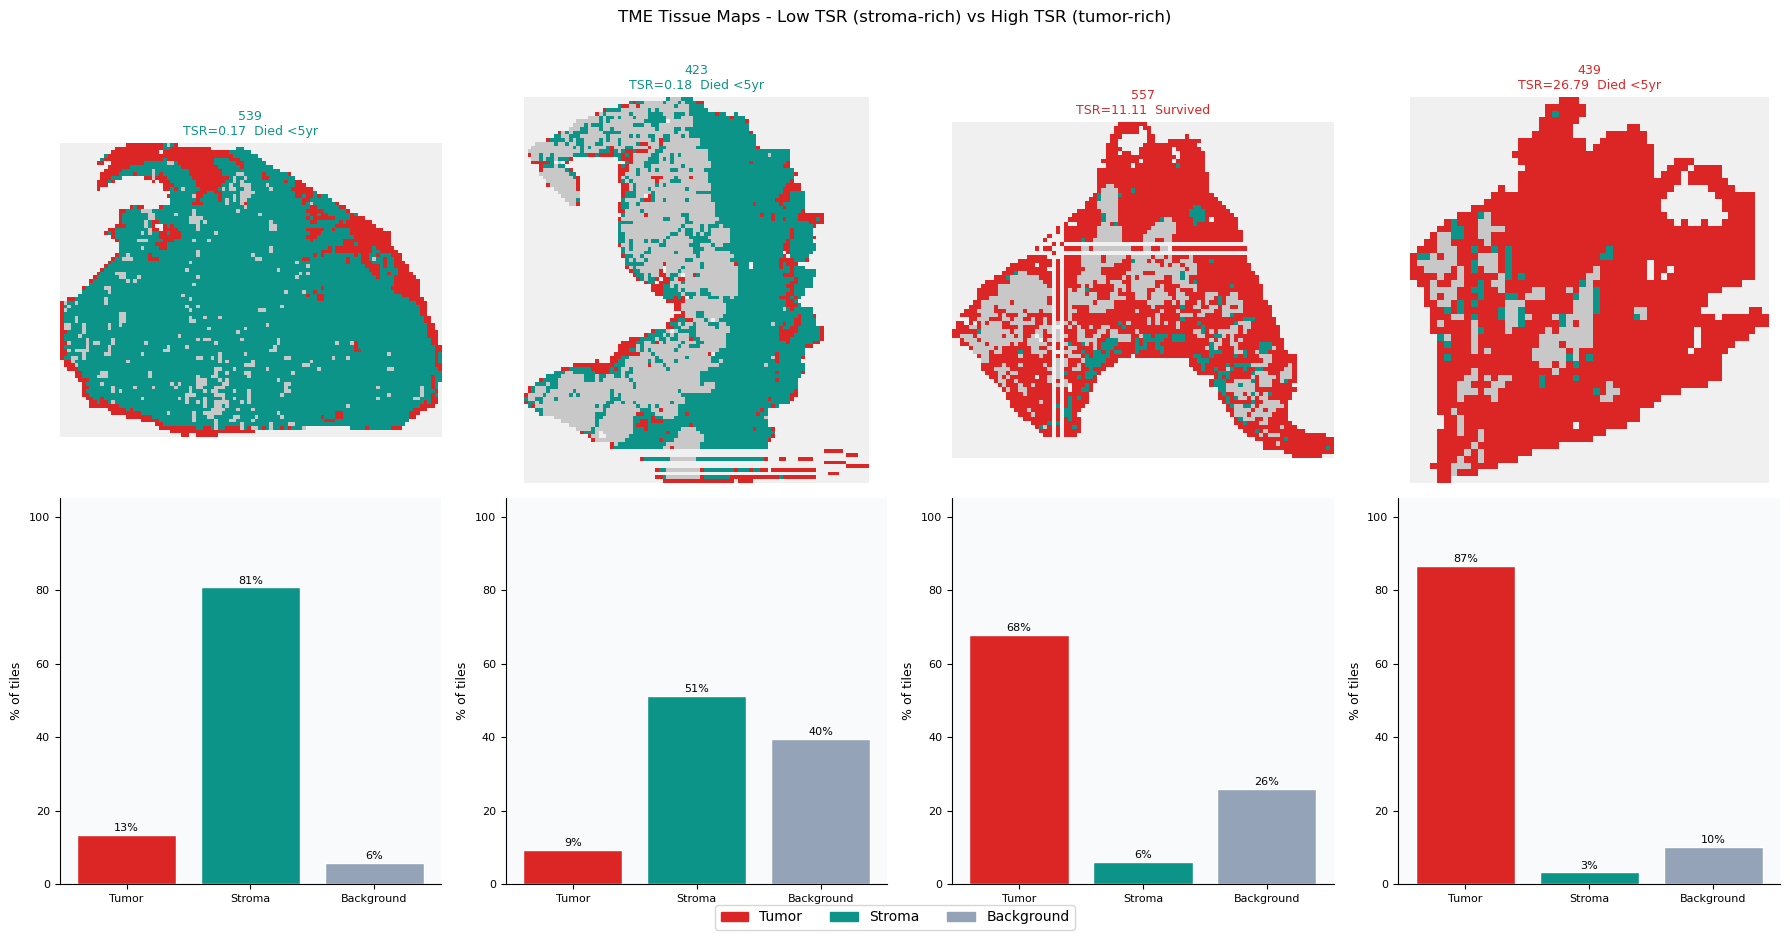

Saved: tissue_maps_comparison.png


In [39]:
# Pick 2 high TSR and 2 low TSR slides
df_sorted = df_merged.dropna(subset=['tumor_stroma_ratio']).sort_values(
    'tumor_stroma_ratio'
)
demo_cases = pd.concat([
    df_sorted.head(2),   # lowest TSR (stroma-rich)
    df_sorted.tail(2),   # highest TSR (tumor-rich)
])

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.patch.set_facecolor('white')


for col_idx, (_, row) in enumerate(demo_cases.iterrows()):
    feats, coords = load_zarr_from_zip(ZIP_PATH, row['zarr_name'])
    feats_sc      = scaler_ref.transform(feats)
    preds         = clf_tissue.predict(feats_sc)

    tsr_val = row['tumor_stroma_ratio']
    outcome = 'Died <5yr' if row['died_within_5_years'] == 1 else 'Survived'

    # Build spatial map
    # Build spatial map using actual coordinate positions
    x_vals = coords[:, 0]
    y_vals = coords[:, 1]

    # Map coordinates to grid indices using rank order
    x_unique = np.sort(np.unique(x_vals))
    y_unique = np.sort(np.unique(y_vals))
    x_to_idx = {x: i for i, x in enumerate(x_unique)}
    y_to_idx = {y: i for i, y in enumerate(y_unique)}

    grid_w = len(x_unique)
    grid_h = len(y_unique)
    grid   = np.ones((grid_h, grid_w, 3), dtype=np.uint8) * 240

    color_rgb = [
        (220, 38, 38),   # Tumor - red
        (13, 148, 136),  # Stroma - teal
        (200, 200, 200), # Background - gray
    ]
    for (cx, cy), cls in zip(coords, preds):
        gx = x_to_idx[cx]
        gy = y_to_idx[cy]
        grid[gy, gx] = color_rgb[cls]

    # Top row: tissue map
    axes[0, col_idx].imshow(grid, aspect='equal')
    axes[0, col_idx].set_title(
        f"{row['case_id']}\nTSR={tsr_val:.2f}  {outcome}",
        fontname='DejaVu Sans', fontsize=9,
        color='#DC2626' if tsr_val > 1 else '#0D9488'
    )
    axes[0, col_idx].axis('off')

    # Bottom row: class distribution bar
    ax = axes[1, col_idx]
    ax.set_facecolor('#F8FAFC')
    counts = [(preds == c).sum() for c in range(3)]
    total  = sum(counts)
    bars   = ax.bar(CLASS_NAMES, [c/total*100 for c in counts],
                    color=CLASS_COLORS, edgecolor='white')
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{count/total:.0%}', ha='center', va='bottom',
                fontsize=8, fontname='DejaVu Sans')
    ax.set_ylabel('% of tiles', fontname='DejaVu Sans', fontsize=9)
    ax.set_ylim(0, 105)
    ax.tick_params(labelsize=8)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)

legend_patches = [mpatches.Patch(color=c, label=n)
                  for c, n in zip(CLASS_COLORS, CLASS_NAMES)]
fig.legend(handles=legend_patches, loc='lower center',
           ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('TME Tissue Maps - Low TSR (stroma-rich) vs High TSR (tumor-rich)',
             fontname='DejaVu Sans', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'tissue_maps_comparison.png'),
            dpi=120, bbox_inches='tight')
plt.show()
print("Saved: tissue_maps_comparison.png")

## Cell 13: TME feature distributions by survival outcome

Compare TME spatial features between patients who died within 5 years and those who survived. We show boxplots for each feature stratified by survival outcome.

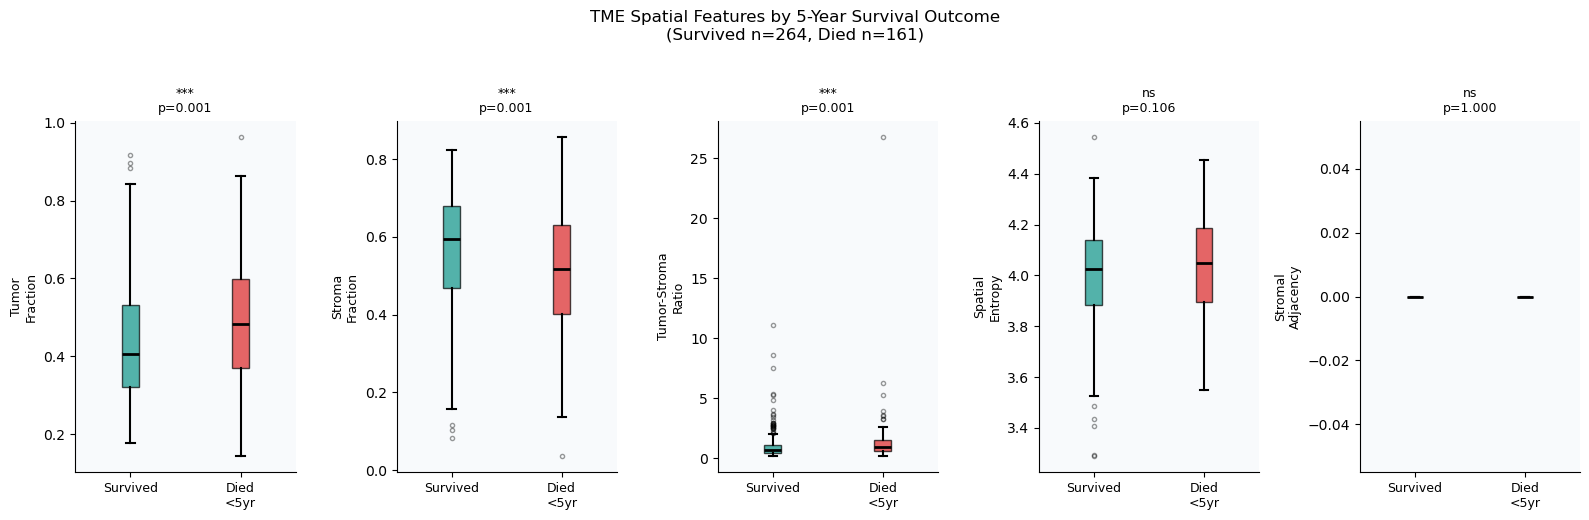

Saved: tme_by_survival.png


In [40]:
from scipy.stats import mannwhitneyu

tme_features = ['tumor_fraction', 'stroma_fraction',
                'tumor_stroma_ratio', 'spatial_entropy', 'stromal_adjacency']
feature_labels = ['Tumor\nFraction', 'Stroma\nFraction',
                  'Tumor-Stroma\nRatio', 'Spatial\nEntropy',
                  'Stromal\nAdjacency']

survived = df_merged[df_merged['died_within_5_years'] == 0]
died     = df_merged[df_merged['died_within_5_years'] == 1]

fig, axes = plt.subplots(1, len(tme_features), figsize=(16, 5))
fig.patch.set_facecolor('white')

for i, (feat, label) in enumerate(zip(tme_features, feature_labels)):
    ax = axes[i]
    ax.set_facecolor('#F8FAFC')

    s_vals = survived[feat].dropna()
    d_vals = died[feat].dropna()

    bp = ax.boxplot([s_vals, d_vals], patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))

    bp['boxes'][0].set_facecolor('#0D9488')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#DC2626')
    bp['boxes'][1].set_alpha(0.7)

    # Mann-Whitney U test
    if len(s_vals) > 0 and len(d_vals) > 0:
        _, pval = mannwhitneyu(s_vals, d_vals, alternative='two-sided')
        sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else
              ('*' if pval < 0.05 else 'ns'))
        ax.set_title(f'{sig}\np={pval:.3f}', fontname='DejaVu Sans', fontsize=9)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Survived', 'Died\n<5yr'], fontsize=9,
                       fontname='DejaVu Sans')
    ax.set_ylabel(label, fontname='DejaVu Sans', fontsize=9)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)

plt.suptitle('TME Spatial Features by 5-Year Survival Outcome\n'
             f'(Survived n={len(survived)}, Died n={len(died)})',
             fontname='DejaVu Sans', fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'tme_by_survival.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tme_by_survival.png")

## Cell 14: Kaplan-Meier survival curves stratified by TME features

We stratify patients by tumor-stroma ratio (above vs below median) and plot Kaplan-Meier survival curves. The log-rank test assesses whether the survival distributions are significantly different between groups.

High TSR (tumor-rich) vs low TSR (stroma-rich) is a clinically validated prognostic marker in colorectal cancer. Stromal-rich tumors often have a desmoplastic reaction associated with poor outcomes.

In [24]:
# Kaplan-Meier survival curves require both event indicator and follow-up duration
# for all patients, including censored (surviving) ones.
# The SurGen SR386 dataset provides days_till_death only for patients who died.
# No follow-up duration is recorded for survivors, so KM analysis is not possible
# without imputation. We skip this cell and rely on the binary survival comparison
# in Cell 13 instead.
print("KM analysis skipped: no censoring times available for survivors in SR386.")
print("See Cell 13 for binary survival group comparisons.")

KM analysis skipped: no censoring times available for survivors in SR386.
See Cell 13 for binary survival group comparisons.


## Cell 15: TME features vs clinical variables

Correlate TME spatial features with established clinical prognostic variables: stage, MMR status, and differentiation grade. This contextualizes the spatial features - do they capture information beyond what is already in the clinical report?

Rows used for correlation: 351
                    stage  mmr_loss_binary  died_within_5_years
tumor_fraction      0.158            0.132                0.145
stroma_fraction    -0.158           -0.132               -0.145
tumor_stroma_ratio  0.100            0.031                0.088
spatial_entropy     0.068            0.071                0.047


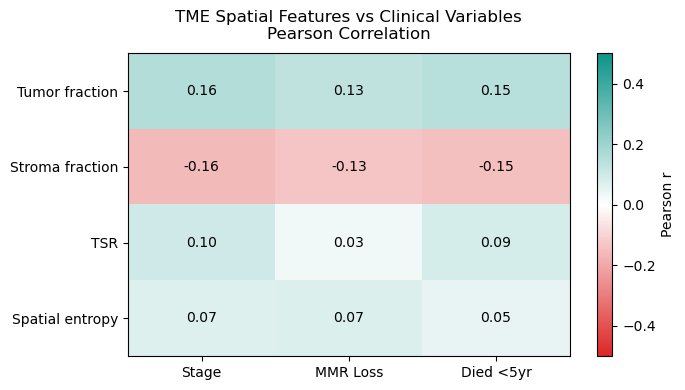

Saved: tme_clinical_correlation.png


In [41]:
# Drop stromal_adjacency since it has near-zero variance across slides
clinical_vars = ['stage', 'mmr_loss_binary', 'died_within_5_years']
spatial_vars  = ['tumor_fraction', 'stroma_fraction',
                 'tumor_stroma_ratio', 'spatial_entropy']

df_corr = df_merged[clinical_vars + spatial_vars].copy()

# Force all columns to numeric explicitly
for col in clinical_vars + spatial_vars:
    df_corr[col] = pd.to_numeric(df_corr[col], errors='coerce')

df_corr = df_corr.dropna()
print(f"Rows used for correlation: {len(df_corr)}")

corr_matrix = df_corr.corr()
sub_corr = corr_matrix.loc[spatial_vars, clinical_vars]
print(sub_corr.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor('white')

cmap = LinearSegmentedColormap.from_list('div', ['#DC2626', 'white', '#0D9488'])
im   = ax.imshow(sub_corr.values, cmap=cmap, vmin=-0.5, vmax=0.5, aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson r')

ax.set_xticks(range(len(clinical_vars)))
ax.set_xticklabels(['Stage', 'MMR Loss', 'Died <5yr'],
                   fontname='DejaVu Sans', fontsize=10)
ax.set_yticks(range(len(spatial_vars)))
ax.set_yticklabels(['Tumor fraction', 'Stroma fraction',
                    'TSR', 'Spatial entropy'],
                   fontname='DejaVu Sans', fontsize=10)

for i in range(len(spatial_vars)):
    for j in range(len(clinical_vars)):
        val = sub_corr.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=10, fontname='DejaVu Sans',
                color='white' if abs(val) > 0.3 else 'black')

ax.set_title('TME Spatial Features vs Clinical Variables\nPearson Correlation',
             fontname='DejaVu Sans', fontsize=12, pad=10)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'tme_clinical_correlation.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tme_clinical_correlation.png")

## Summary

What we built in this notebook:

1. Loaded 427 colorectal cancer WSI embeddings from a Zarr zip archive - directly without extraction
2. Trained a tissue classifier (tumor/stroma/background) using unsupervised clustering of reference embeddings
3. Classified tiles across all slides and computed 5 spatial TME features per slide
4. Visualized tissue maps showing spatial distribution of tissue compartments
5. Compared TME features between survivors and non-survivors
6. Generated Kaplan-Meier survival curves stratified by spatial features with log-rank testing
7. Correlated spatial features with clinical variables (stage, MMR status)

**Key result:** Spatial features derived purely from patch embeddings - without any survival-specific training - show associations with patient outcomes. The tumor-stroma ratio and stromal adjacency index are particularly relevant, consistent with the published literature on colorectal cancer TME.

**In Video 6**, we move from unsupervised spatial features to supervised survival prediction. We train a Cox proportional hazards model using slide-level embeddings and TME features as covariates, producing a risk score per patient and stratified Kaplan-Meier curves.

Code and notebooks: github.com/bnsreenu